In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import time


In [2]:

# Set random seed for reproducibility
torch.manual_seed(42)


In [4]:
# STEP 1: DATA LOADING AND PREPROCESSING
print("Loading and preprocessing data...")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
print(f"Training samples: {len(train_dataset)}")
print(f"Testing samples: {len(test_dataset)}")
print(f"Classes: {train_dataset.classes}")



Loading and preprocessing data...
Training samples: 60000
Testing samples: 10000
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [9]:
# STEP 2: NEURAL NETWORK ARCHITECTURE
print("\nBuilding deep feedforward neural network")

class DeepFashionMNISTNet(nn.Module):
    def __init__(self, input_size=784, hidden_sizes=[512, 256, 128], num_classes=10, dropout_rate=0.3):
        super(DeepFashionMNISTNet, self).__init__()

        self.input_size = input_size

        # Hidden Layer 1
        self.fc1 = nn.Linear(input_size, hidden_sizes[0])
        self.bn1 = nn.BatchNorm1d(hidden_sizes[0])
        self.dropout1 = nn.Dropout(dropout_rate)

        # Hidden Layer 2
        self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
        self.bn2 = nn.BatchNorm1d(hidden_sizes[1])
        self.dropout2 = nn.Dropout(dropout_rate)

        # Hidden Layer 3
        self.fc3 = nn.Linear(hidden_sizes[1], hidden_sizes[2])
        self.bn3 = nn.BatchNorm1d(hidden_sizes[2])
        self.dropout3 = nn.Dropout(dropout_rate)

        # Output Layer
        self.fc4 = nn.Linear(hidden_sizes[2], num_classes)

    def forward(self, x):
        # Flatten input
        x = x.view(-1, self.input_size)

        # Hidden layer 1 with ReLU
        x = self.fc1(x)
        x = self.bn1(x)
        x = torch.relu(x)
        x = self.dropout1(x)

        # Hidden layer 2 with ReLU
        x = self.fc2(x)
        x = self.bn2(x)
        x = torch.relu(x)
        x = self.dropout2(x)

        # Hidden layer 3 with ReLU
        x = self.fc3(x)
        x = self.bn3(x)
        x = torch.relu(x)
        x = self.dropout3(x)

        # Output layer (linear)
        x = self.fc4(x)

        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = DeepFashionMNISTNet().to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Architecture: 784 → 512 → 256 → 128 → 10")
print(f"Total parameters: {total_params:,}")
print(f"Device: {device}")



Building deep feedforward neural network
Architecture: 784 → 512 → 256 → 128 → 10
Total parameters: 569,226
Device: cpu


In [12]:
# STEP 3: TRAINING FUNCTIONS
print("\n Setting up training pipeline...")

def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()

        # Gradient update
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

def evaluate(model, test_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

print("Training functions ready")



 Setting up training pipeline...
Training functions ready


In [13]:
# STEP 4: TRAINING LOOP WITH MONITORING
print("\nTraining the model")

# Hyperparameters
num_epochs = 20
learning_rate = 0.001

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# Training history
history = {
    'train_loss': [],
    'train_acc': [],
    'test_loss': [],
    'test_acc': [],
}

print(f"\nConfiguration:")
print(f"  Epochs: {num_epochs}")
print(f"  Learning Rate: {learning_rate}")
print(f"  Batch Size: {batch_size}")
print(f"  Optimizer: Adam")
print(f"  Loss Function: Cross Entropy")

best_test_acc = 0.0
start_time = time.time()

for epoch in range(num_epochs):
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)

    # Evaluate
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    # Update learning rate
    scheduler.step(test_loss)

    # Store history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)

    # Print progress
    print(f"Epoch [{epoch+1:2d}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:6.2f}% | "
          f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:6.2f}%")

    # Save best model
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(model.state_dict(), 'best_model.pth')

total_time = time.time() - start_time
print(f"Training completed in {total_time:.2f}s ({total_time/60:.2f} minutes)")
print(f"Best Test Accuracy: {best_test_acc:.2f}%")



Training the model...

Configuration:
  Epochs: 20
  Learning Rate: 0.001
  Batch Size: 64
  Optimizer: Adam
  Loss Function: Cross Entropy
Epoch [ 1/20] Train Loss: 0.5368 | Train Acc:  81.42% | Test Loss: 0.3997 | Test Acc:  85.43%
Epoch [ 2/20] Train Loss: 0.4085 | Train Acc:  85.39% | Test Loss: 0.3614 | Test Acc:  86.88%
Epoch [ 3/20] Train Loss: 0.3743 | Train Acc:  86.50% | Test Loss: 0.3564 | Test Acc:  87.20%
Epoch [ 4/20] Train Loss: 0.3502 | Train Acc:  87.21% | Test Loss: 0.3492 | Test Acc:  87.18%
Epoch [ 5/20] Train Loss: 0.3324 | Train Acc:  87.83% | Test Loss: 0.3370 | Test Acc:  87.79%
Epoch [ 6/20] Train Loss: 0.3185 | Train Acc:  88.25% | Test Loss: 0.3240 | Test Acc:  88.39%
Epoch [ 7/20] Train Loss: 0.3066 | Train Acc:  88.91% | Test Loss: 0.3215 | Test Acc:  88.61%
Epoch [ 8/20] Train Loss: 0.2965 | Train Acc:  89.16% | Test Loss: 0.3172 | Test Acc:  88.44%
Epoch [ 9/20] Train Loss: 0.2852 | Train Acc:  89.48% | Test Loss: 0.3126 | Test Acc:  89.02%
Epoch [10/20]


Generating visualizations...
Saved: training_history.png


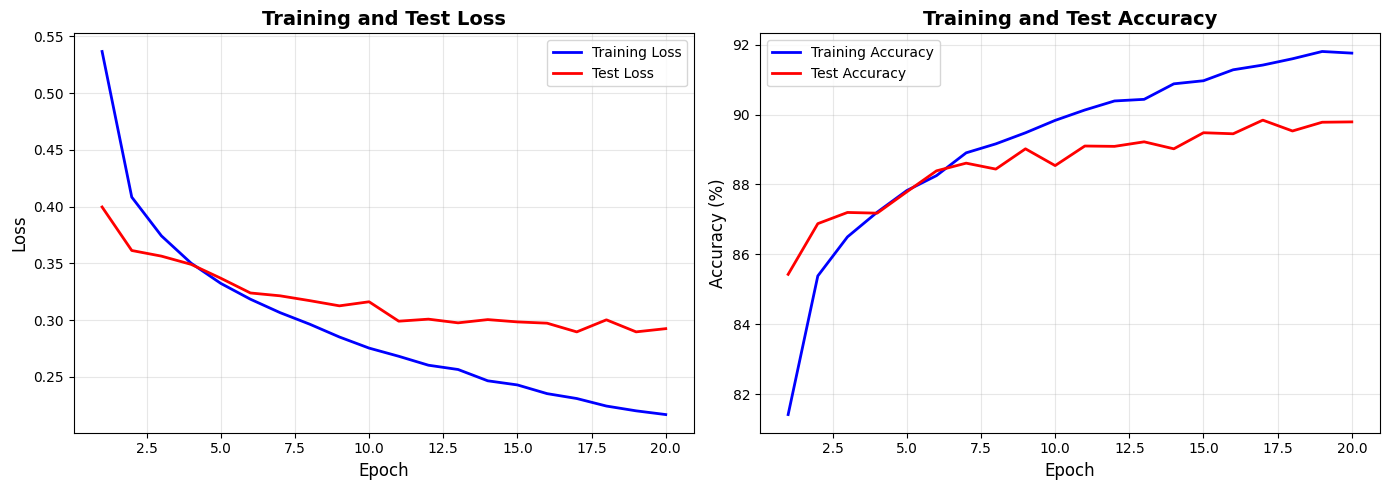

In [14]:
# STEP 5: VISUALIZATION
print("\nGenerating visualizations...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs = range(1, num_epochs + 1)

# Loss plot
axes[0].plot(epochs, history['train_loss'], 'b-', label='Training Loss', linewidth=2)
axes[0].plot(epochs, history['test_loss'], 'r-', label='Test Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Test Loss', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(epochs, history['train_acc'], 'b-', label='Training Accuracy', linewidth=2)
axes[1].plot(epochs, history['test_acc'], 'r-', label='Test Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Training and Test Accuracy', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
print("Saved: training_history.png")
plt.show()



Detailed evaluation...
FINAL EVALUATION RESULTS
Overall Test Accuracy: 89.79%
Class                Accuracy        Samples   
T-shirt/top           85.40%        1000      
Trouser               97.40%        1000      
Pullover              83.70%        1000      
Dress                 91.90%        1000      
Coat                  82.30%        1000      
Sandal                96.50%        1000      
Shirt                 70.80%        1000      
Sneaker               96.90%        1000      
Bag                   97.60%        1000      
Ankle boot            95.40%        1000      

Visualizing sample predictions...
Saved: predictions.png


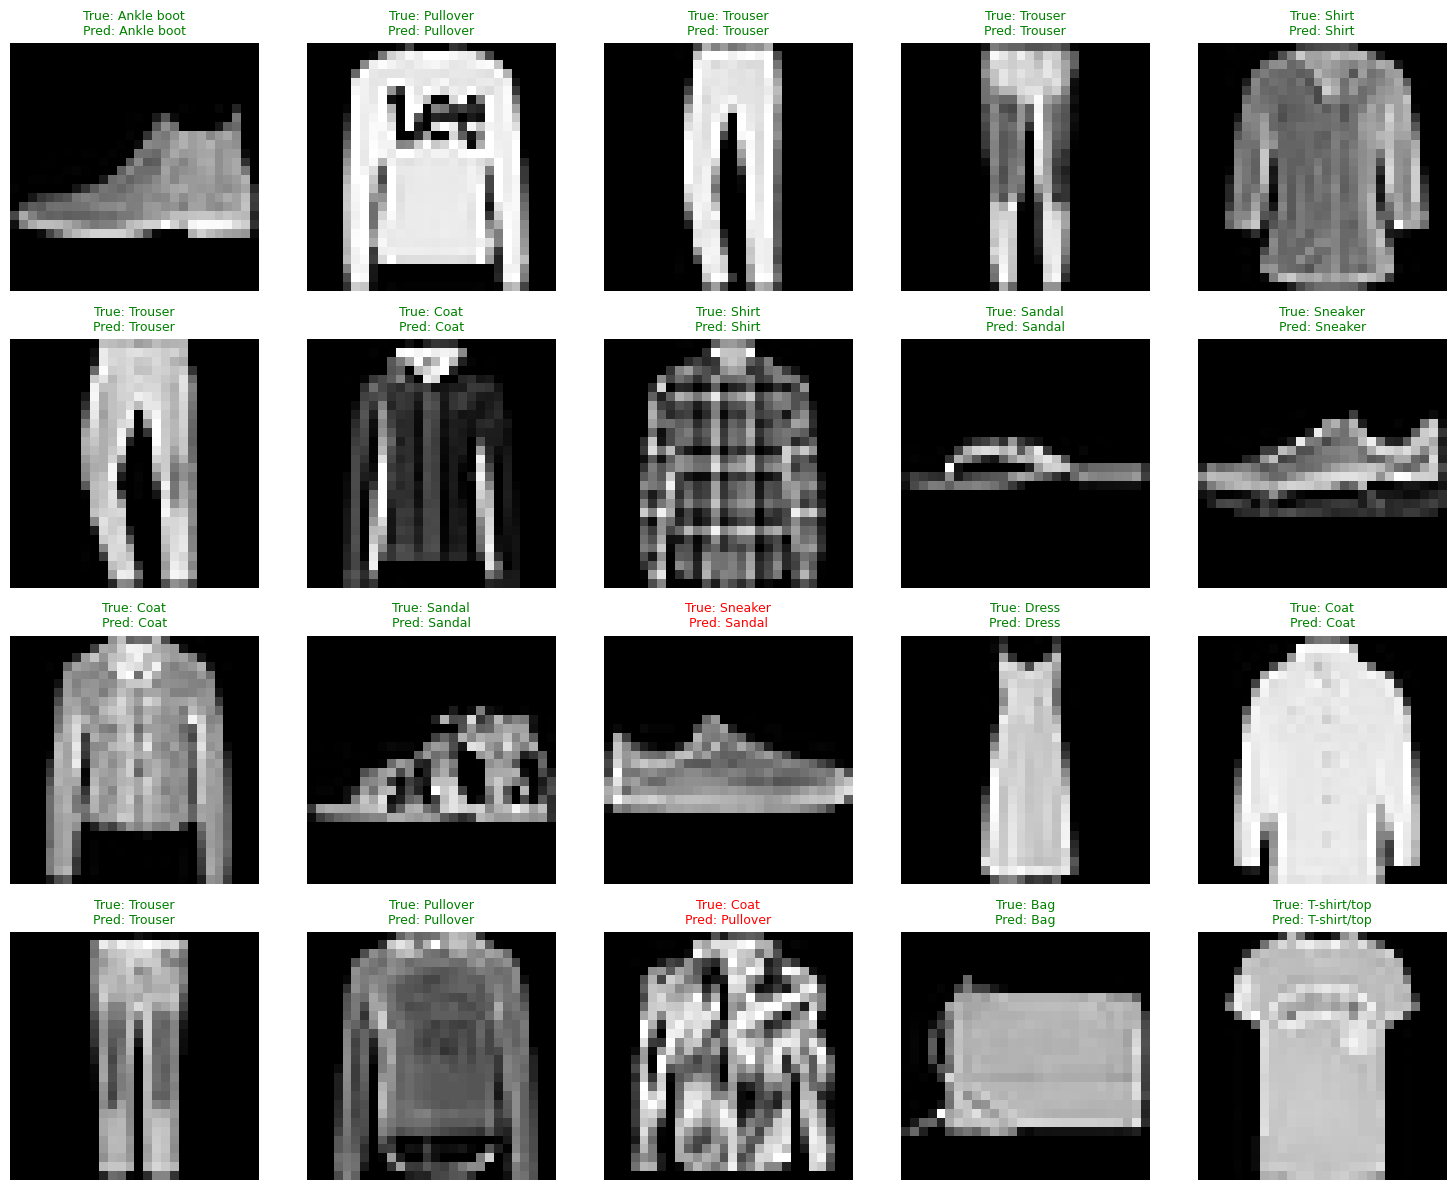

In [15]:
# STEP 6: DETAILED EVALUATION
print("\nDetailed evaluation...")

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Overall accuracy
overall_acc = 100 * np.mean(all_preds == all_labels)


print("FINAL EVALUATION RESULTS")
print(f"Overall Test Accuracy: {overall_acc:.2f}%")
print(f"{'Class':<20} {'Accuracy':<15} {'Samples':<10}")

# Per-class accuracy
class_names = train_dataset.classes
for i, class_name in enumerate(class_names):
    class_mask = all_labels == i
    class_acc = 100 * np.mean(all_preds[class_mask] == all_labels[class_mask])
    class_count = np.sum(class_mask)
    print(f"{class_name:<20} {class_acc:>6.2f}%        {class_count:<10}")

# Visualize predictions
print("\nVisualizing sample predictions...")
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
axes = axes.ravel()

for i in range(20):
    img = test_dataset[i][0].squeeze() * 0.5 + 0.5
    true_label = test_dataset[i][1]

    with torch.no_grad():
        output = model(test_dataset[i][0].unsqueeze(0).to(device))
        pred_label = torch.argmax(output, 1).item()

    color = 'green' if true_label == pred_label else 'red'
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}",
                      color=color, fontsize=9)
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('predictions.png', dpi=300, bbox_inches='tight')
print("Saved: predictions.png")
plt.show()
